In [1]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
import os
import json
import pandas as pd
from pathlib import Path


results_dir = Path().resolve() / "runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),

            
            "cxpb": h.get("cxpb"),
            "mutpb": h.get("mutpb"),
            "mutation_rate": h.get("mutation_rate"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())

✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,cxpb,mutpb,mutation_rate,popsize,generations,L_used,runtime_sec_meta
0,1,101,generic,438.65,43851.275,438.51275,35.531988,995,False,1.95,0.004465,0.187216,0.304436,0.097634,22,100,None,35.531988
1,1,202,generic,438.65,43845.425,438.45425,34.936952,984,False,1.95,0.004465,0.187216,0.304436,0.097634,22,100,None,34.936952
2,1,303,generic,438.65,43853.750,438.53750,34.351741,970,False,2.10,0.004810,0.187216,0.304436,0.097634,22,100,None,34.351741
3,1,404,generic,438.65,43852.475,438.52475,34.657747,957,False,1.65,0.003776,0.187216,0.304436,0.097634,22,100,None,34.657747
4,1,505,generic,438.65,43858.925,438.58925,39.755592,1001,False,1.95,0.004465,0.187216,0.304436,0.097634,22,100,None,39.755592


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 569.377, p = 3.476e-67


In [4]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
73,910.590909,80.598331,11,360.090909
70,903.136364,135.502784,11,352.636364
60,877.272727,147.612900,11,326.772727
38,872.363636,208.371074,11,321.863636
56,865.181818,188.012669,11,314.681818
18,843.909091,165.487887,11,293.409091
75,830.454545,172.406707,11,279.954545
2,829.818182,191.075806,11,279.318182
22,828.681818,161.582993,11,278.181818


C:\Users\57305\AppData\Local\Temp\ipykernel_9400\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


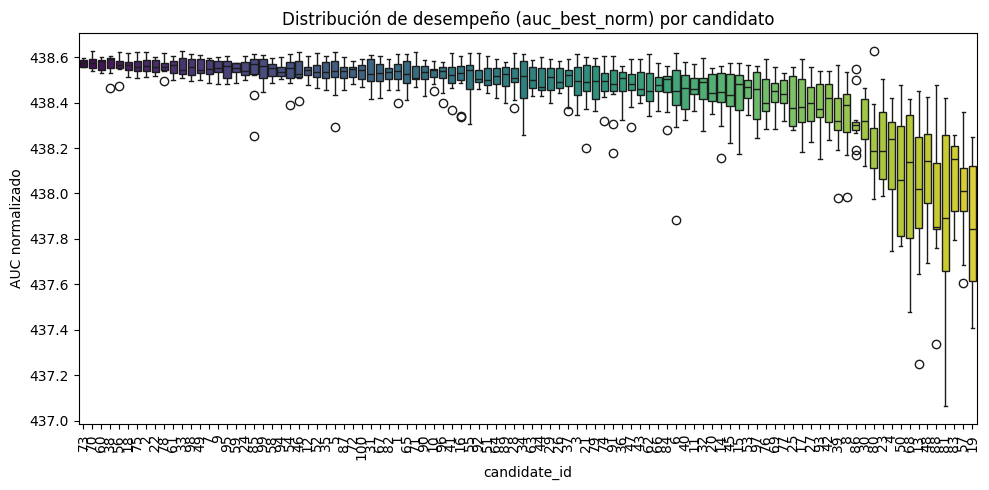

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


KeyboardInterrupt: 

In [ ]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [ ]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,22 > 23,11,11,121.0,0.000041,0.200817,False
1,2 > 4,11,11,121.0,0.000041,0.200817,False
2,2 > 19,11,11,121.0,0.000041,0.200817,False
3,78 > 88,11,11,121.0,0.000041,0.200817,False
4,22 > 30,11,11,121.0,0.000041,0.200817,False
...,...,...,...,...,...,...,...
4945,30 > 33,11,11,0.0,0.999969,4949.847605,False
4946,68 > 92,11,11,0.0,0.999969,4949.847605,False
4947,57 > 73,11,11,0.0,0.999969,4949.847605,False
4948,13 > 49,11,11,0.0,0.999969,4949.847605,False


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,1,2,1 > 2,11,11.5,0.974609,1.0,False,1.0,False
1,1,3,1 > 3,11,49.0,0.087402,1.0,False,1.0,False
2,1,4,1 > 4,11,66.0,0.000488,1.0,False,1.0,False
3,1,5,1 > 5,11,22.0,0.829102,1.0,False,1.0,False
4,1,6,1 > 6,11,50.0,0.073730,1.0,False,1.0,False
5,1,7,1 > 7,11,19.0,0.896973,1.0,False,1.0,False
6,1,8,1 > 8,11,64.0,0.001465,1.0,False,1.0,False
7,1,9,1 > 9,11,21.0,0.860840,1.0,False,1.0,False
8,1,10,1 > 10,11,37.0,0.382324,1.0,False,1.0,False
9,1,11,1 > 11,11,59.0,0.009277,1.0,False,1.0,False


In [ ]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [ ]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
...,...,...,...
96,0,0,0
97,0,0,0
98,0,0,0
99,0,0,0


# Candidatos

In [ ]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 73            438.573705  0.015389  438.565297
 70            438.575477  0.028463  438.559927
 60            438.569068  0.026613  438.554529
 18            438.563750  0.032000  438.546267
 56            438.566886  0.040444  438.544790
 22            438.560205  0.028925  438.544402
 38            438.567159  0.041971  438.544229
 75            438.561568  0.033937  438.543027
 78            438.558568  0.030798  438.541742
 2             438.561977  0.038221  438.541096,
 [73, 70, 60, 18, 56, 22, 38, 75, 78, 2])

In [ ]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,70,18,11,55.0,0.026855,1.0,False,1.0,False
1,73,22,11,53.0,0.041504,1.0,False,1.0,False
2,70,56,11,52.0,0.050781,1.0,False,1.0,False
3,60,22,11,50.0,0.072266,1.0,False,1.0,False
4,70,22,11,48.0,0.103027,1.0,False,1.0,False
5,70,78,11,48.0,0.103027,1.0,False,1.0,False
6,70,75,11,47.0,0.120117,1.0,False,1.0,False
7,73,75,11,47.0,0.120117,1.0,False,1.0,False
8,70,2,11,46.5,0.124512,1.0,False,1.0,False
9,73,18,11,46.5,0.124512,1.0,False,1.0,False


In [ ]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
2,0,0,0,0.0
18,0,0,0,0.0
22,0,0,0,0.0
38,0,0,0,0.0
56,0,0,0,0.0
60,0,0,0,0.0
70,0,0,0,0.0
73,0,0,0,0.0
75,0,0,0,0.0
78,0,0,0,0.0


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import t

metric = "auc_best_norm"
top = 10  # tamaño del shortlist

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico unil. 95% por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))
lcb95 = mean - tcrit * se
p10   = g.quantile(0.10)

df_lcb = (pd.DataFrame({
    "auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10
}).sort_values(["lcb95","p10","auc_mean"], ascending=[False, False, False]))

short_candidates = df_lcb.head(top).index.tolist()
display(df_lcb.head(top))
print("Shortlist:", short_candidates)


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
73,438.573705,0.015389,11,0.004640,438.565295,438.55775
70,438.575477,0.028463,11,0.008582,438.559923,438.54425
60,438.569068,0.026613,11,0.008024,438.554525,438.53075
18,438.563750,0.032000,11,0.009648,438.546263,438.52775
56,438.566886,0.040444,11,0.012194,438.544785,438.54650
22,438.560205,0.028925,11,0.008721,438.544398,438.52475
38,438.567159,0.041971,11,0.012655,438.544223,438.53150
75,438.561568,0.033937,11,0.010232,438.543022,438.53000
78,438.558568,0.030798,11,0.009286,438.541738,438.53975


Shortlist: [73, 70, 60, 18, 56, 22, 38, 75, 78, 2]


In [ ]:
import itertools
from scipy.stats import wilcoxon

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

rows = []
for c1, c2 in itertools.combinations(short_candidates, 2):
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5: 
        continue
    d = data[c1] - data[c2]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(d), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

display(df_tests.head(20))

# Tamaño de efecto (Cliff’s delta)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in x for yi in y)
    return (gt - lt) / (len(x) * len(y))

effects = []
for _, r in df_tests.iterrows():
    x = df_finetuning.loc[df_finetuning["candidate_id"]==r["c1"], metric].values
    y = df_finetuning.loc[df_finetuning["candidate_id"]==r["c2"], metric].values
    effects.append({"c1": r["c1"], "c2": r["c2"], "cliffs_delta": cliffs_delta(x, y)})

df_effects = pd.DataFrame(effects).sort_values("cliffs_delta", ascending=False)
display(df_effects.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm
0,70,18,11,55.0,0.026855,1.0,False
1,73,22,11,53.0,0.041504,1.0,False
2,70,56,11,52.0,0.050781,1.0,False
3,60,22,11,50.0,0.072266,1.0,False
4,70,22,11,48.0,0.103027,1.0,False
5,70,78,11,48.0,0.103027,1.0,False
6,70,75,11,47.0,0.120117,1.0,False
7,73,75,11,47.0,0.120117,1.0,False
8,70,2,11,46.5,0.124512,1.0,False
9,73,18,11,46.5,0.124512,1.0,False


,c1,c2,cliffs_delta
10,73,78,0.446281
7,73,75,0.314050
24,60,78,0.289256
1,73,22,0.280992
4,70,22,0.272727
5,70,78,0.272727
9,73,18,0.272727
17,56,78,0.264463
11,73,2,0.247934
6,70,75,0.239669


In [ ]:
from scipy.stats import wilcoxon

def noninferiority_paired(d, Delta):
    # H0: mu_d <= -Delta  vs  H1: mu_d > -Delta
    # Testea d + Delta > 0 (una cola)
    stat, p = wilcoxon(d + Delta, alternative="greater", zero_method="pratt")
    return p

def nosuperiority_paired(d, Delta):
    # H0: mu_d >=  Delta  vs  H1: mu_d <  Delta
    # Testea -(d - Delta) > 0  => Delta - d > 0  (una cola)
    stat, p = wilcoxon(Delta - d, alternative="greater", zero_method="pratt")
    return p

Delta = 0.010  # margen práctico; ajusta a tu unidad

champion = short_candidates[0]  # top por LCB95
pivot_short = pivot[short_candidates].dropna()
tost_rows = []
for c in short_candidates[1:]:
    d = (pivot_short[champion] - pivot_short[c]).dropna()
    if len(d) < 5:
        continue
    p_noninf = noninferiority_paired(d, Delta)
    p_nosup = nosuperiority_paired(d, Delta)
    # Equivalencia si ambas p < alpha
    tost_rows.append({"champion": champion, "challenger": c,
                      "n_seeds": len(d),
                      "p_noninferior": p_noninf, "p_nosuperior": p_nosup,
                      "equivalent_(TOST)": (p_noninf < 0.05) and (p_nosup < 0.05)})

df_tost = pd.DataFrame(tost_rows).sort_values(["equivalent_(TOST)","p_noninferior","p_nosuperior"],
                                              ascending=[False, True, True])
display(df_tost)


,champion,challenger,n_seeds,p_noninferior,p_nosuperior,equivalent_(TOST)
4,73,22,11,0.006836,0.649902,False
6,73,75,11,0.009277,0.711426,False
7,73,78,11,0.012207,0.550781,False
2,73,18,11,0.033691,0.681152,False
8,73,2,11,0.050781,0.517090,False
3,73,56,11,0.061523,0.318848,False
1,73,60,11,0.073730,0.259766,False
0,73,70,11,0.154785,0.059082,False
5,73,38,11,0.182617,0.259766,False


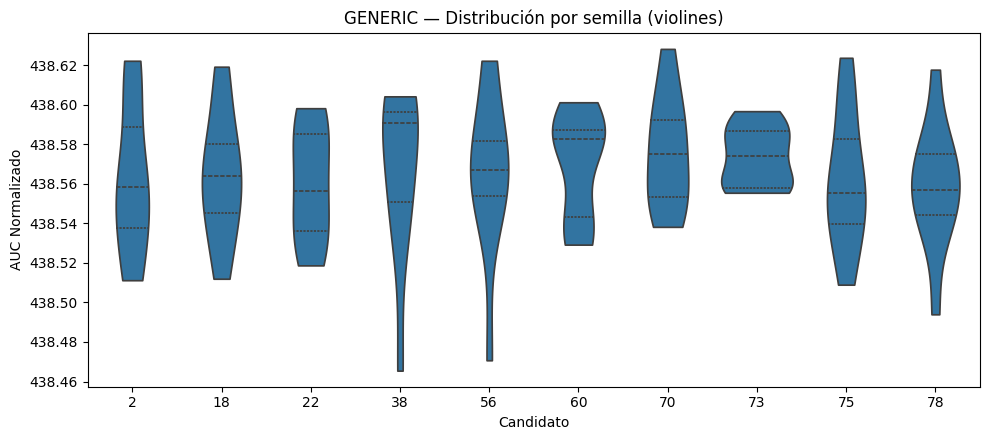

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = [73, 70, 60, 18, 56, 22, 38, 75, 78, 2]
subset = df_finetuning[df_finetuning["candidate_id"].isin(top10)]

plt.figure(figsize=(10,4.5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0)
plt.title("GENERIC — Distribución por semilla (violines)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.tight_layout()
plt.show()


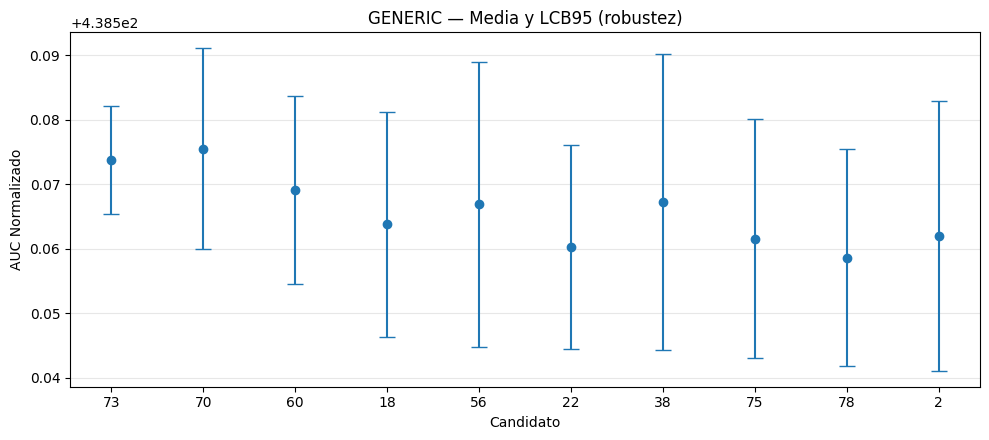

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_lcb.loc[top10, ["auc_mean","lcb95"]].copy()
df_plot["yerr_down"] = df_plot["auc_mean"] - df_plot["lcb95"]

plt.figure(figsize=(10,4.5))
plt.errorbar(df_plot.index.astype(str),
             df_plot["auc_mean"],
             yerr=df_plot["yerr_down"],
             fmt='o', capsize=6)
plt.title("GENERIC — Media y LCB95 (robustez)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


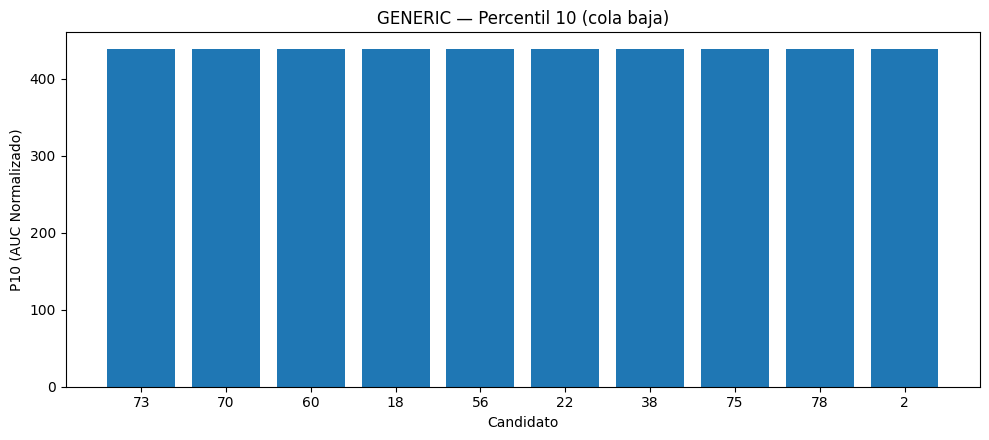

In [ ]:
import matplotlib.pyplot as plt

p10_plot = df_lcb.loc[top10, "p10"]

plt.figure(figsize=(10,4.5))
plt.bar(p10_plot.index.astype(str), p10_plot.values)
plt.title("GENERIC — Percentil 10 (cola baja)")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.tight_layout()
plt.show()


In [ ]:
winner = 73
report = (
    df_lcb.loc[top10, ["auc_mean","auc_std","n","se","lcb95","p10"]]
      .sort_values("lcb95", ascending=False)
)
print("WINNER (robustez):", winner)
display(report)


WINNER (robustez): 73


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
73,438.573705,0.015389,11,0.004640,438.565295,438.55775
70,438.575477,0.028463,11,0.008582,438.559923,438.54425
60,438.569068,0.026613,11,0.008024,438.554525,438.53075
18,438.563750,0.032000,11,0.009648,438.546263,438.52775
56,438.566886,0.040444,11,0.012194,438.544785,438.54650
22,438.560205,0.028925,11,0.008721,438.544398,438.52475
38,438.567159,0.041971,11,0.012655,438.544223,438.53150
75,438.561568,0.033937,11,0.010232,438.543022,438.53000
78,438.558568,0.030798,11,0.009286,438.541738,438.53975


In [ ]:
cid = 73

params_73 = (
    df_finetuning
    .loc[df_finetuning["candidate_id"] == cid, ["cxpb", "mutpb", "mutation_rate"]]
    .iloc[0]
)

params_73



Parámetros de candidate 73:
  cxpb: 0.8266878708773356
  mutpb: 0.4192995101334372
  mutation_rate: 0.10540044763817079


In [ ]:
top3 = df_lcb.sort_values("lcb95", ascending=False).head(3).index.tolist()

df_finetuning[df_finetuning["candidate_id"].isin(top3)][
    ["candidate_id", "cxpb", "mutpb", "mutation_rate", "popsize", "generations"]
].drop_duplicates().sort_values("candidate_id")


,candidate_id,cxpb,mutpb,mutation_rate,popsize,generations
649,60,0.855269,0.496086,0.082949,22,100
759,70,0.822784,0.468664,0.039541,22,100
792,73,0.826688,0.419300,0.105400,22,100
